In [ ]:
import pandas as pd
from sklearn import datasets
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import tree

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
#data
taxi_trips=pd.read_csv("/content/taxi_trips.csv")
taxi_trips

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435
...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373


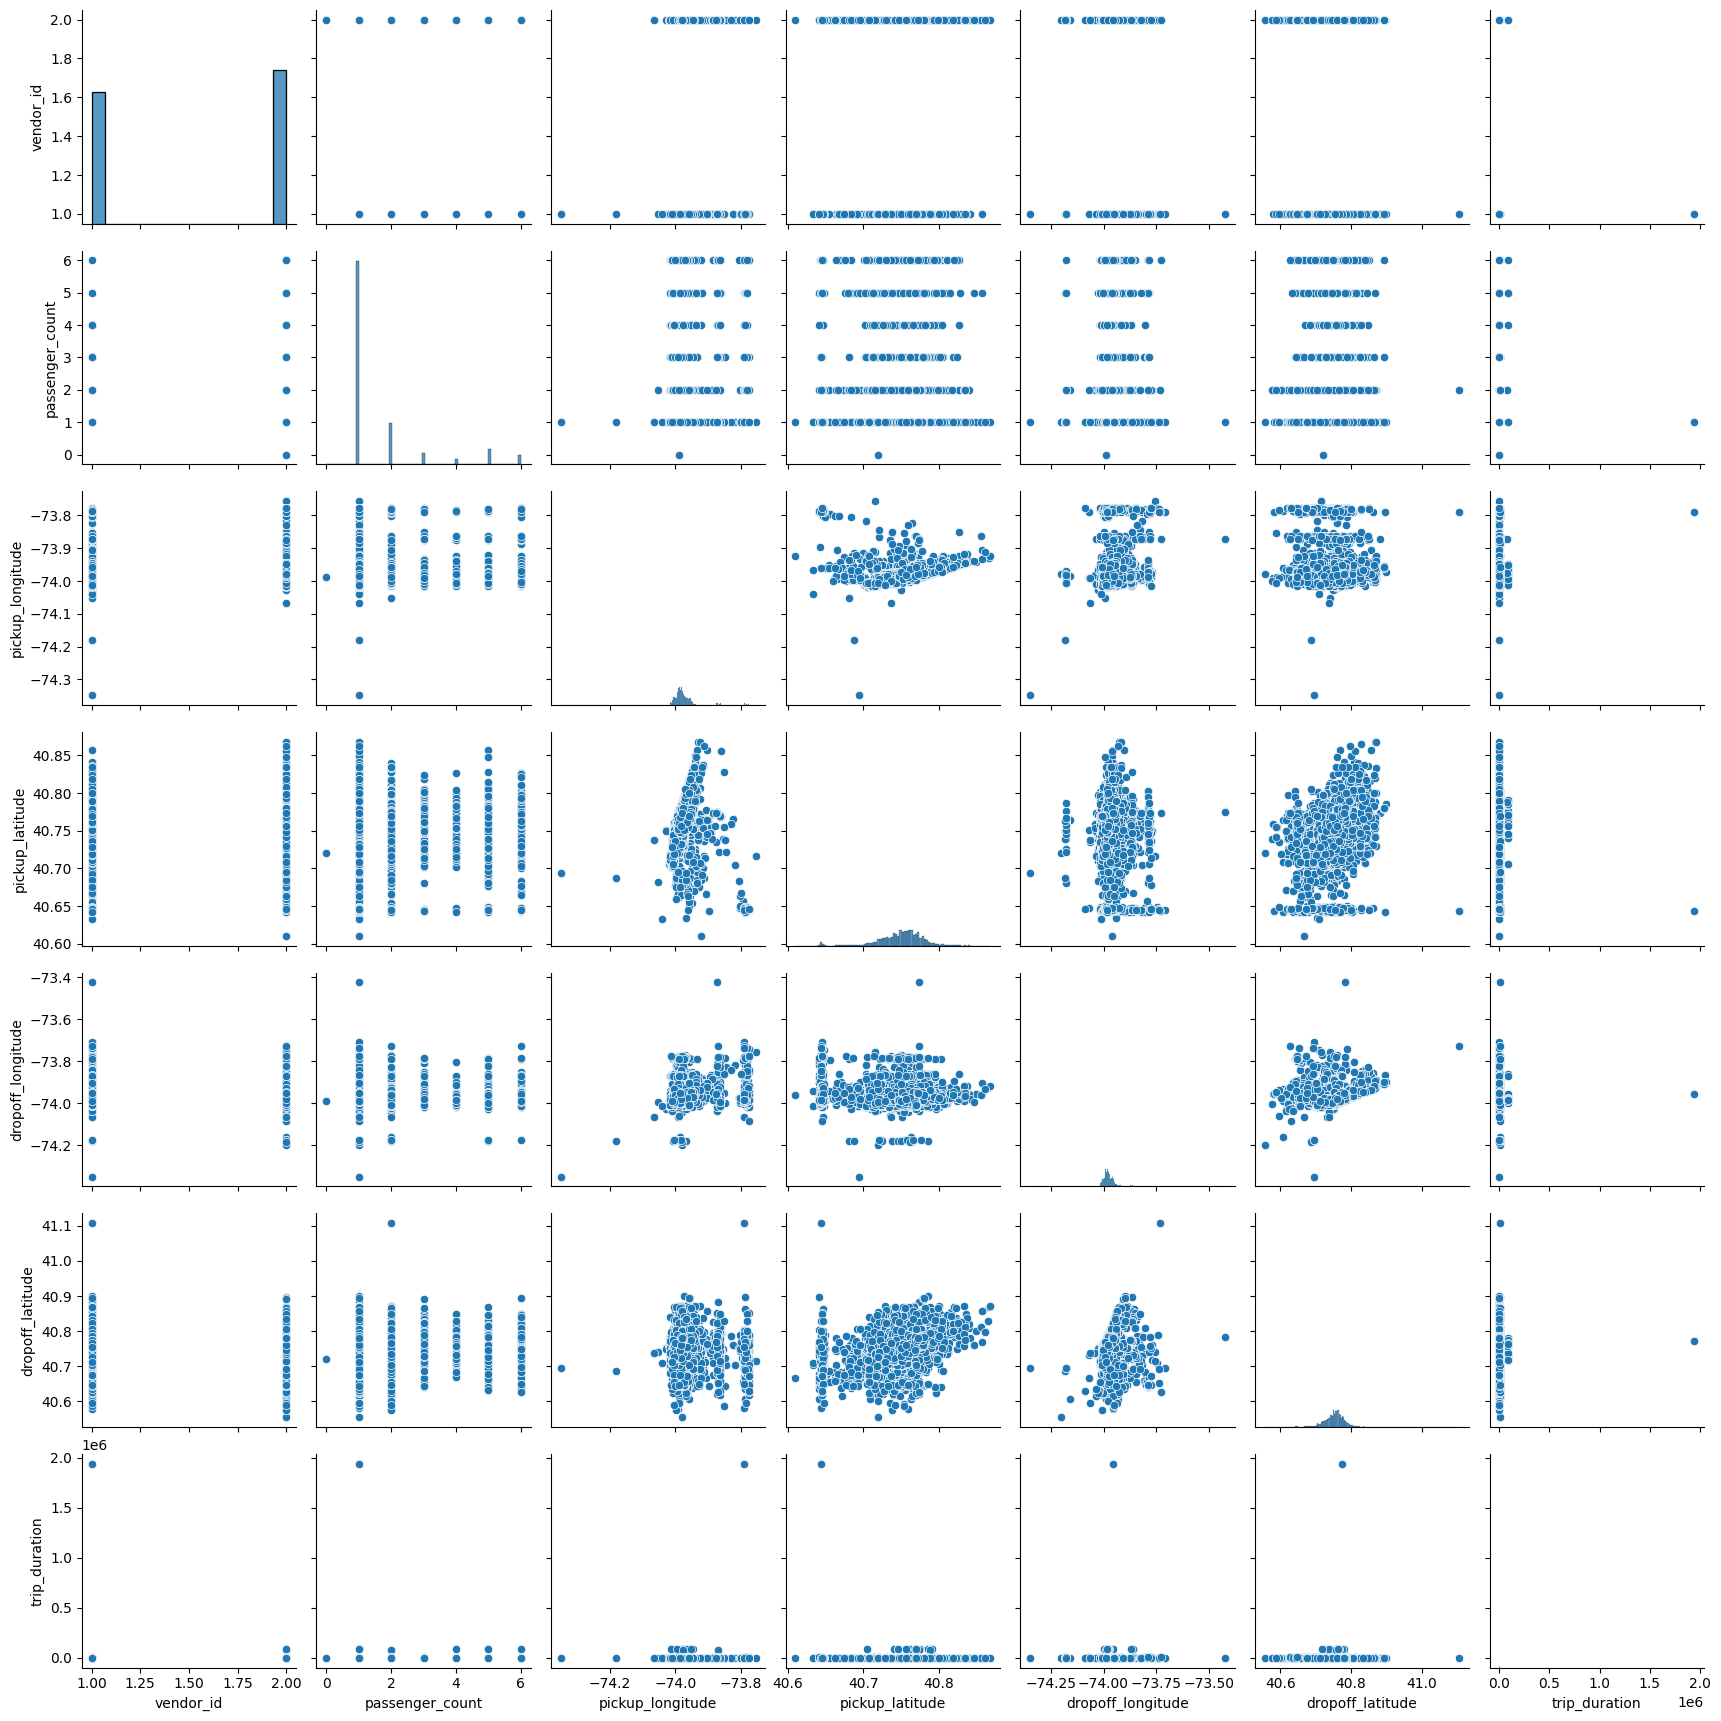

In [ ]:
#The dataset includes over 1 million rows, will take a sample for general observation of the relationshhips
taxi_sample = taxi_trips.sample(n=10000, random_state=11)

sns.pairplot(taxi_sample)

plt.show()

In [ ]:
#handeling outliers, first examing orginal datafram

import numpy as np

#sample data frame

data = {
    'trip_duration': np.append(np.random.normal(900, 300, 1000), [10, 5000, 86400]),
    'pickup_latitude': np.append(np.random.uniform(40.6, 40.9, 1000), [0, 41.5, 40.7]),
    'pickup_longitude': np.append(np.random.uniform(-74.1, -73.7, 1000), [-100, -73.0, -74.0]),
    'dropoff_latitude': np.append(np.random.uniform(40.6, 40.9, 1000), [95, 40.5, 40.8]),
    'dropoff_longitude': np.append(np.random.uniform(-74.1, -73.7, 1000), [0, -75.0, -73.9]),
}
df = pd.DataFrame(data)

print("Original DataFrame shape:", df.shape)

Original DataFrame shape: (1003, 5)


In [ ]:
#handling outliers in trip duration

#capping using Interquartile Range(TQR)
Q1_duration = df['trip_duration'].quantile(0.25)
Q3_duration = df['trip_duration'].quantile(0.75)
IQR_duration = Q3_duration - Q1_duration

# define outlier bounds
lower_bound_duration = Q1_duration - 1.5 * IQR_duration
upper_bound_duration = Q3_duration + 1.5 * IQR_duration

print(f"\nTrip Duration IQR Bounds: Lower={lower_bound_duration:.2f}, Upper={upper_bound_duration:.2f}")

# capping: Replace values outside the bounds with the bounds themselves
df['trip_duration'] = np.where(df['trip_duration'] < lower_bound_duration, lower_bound_duration, df['trip_duration'])
df['trip_duration'] = np.where(df['trip_duration'] > upper_bound_duration, upper_bound_duration, df['trip_duration'])


Trip Duration IQR Bounds: Lower=71.19, Upper=1744.04


In [ ]:
#handling outliers in Latitude and Longitude

# Define reasonable geographical bounds for a city like NYC
# These are approximate bounds, adjust as needed for your specific dataset
NYC_LAT_MIN, NYC_LAT_MAX = 40.62, 40.9
NYC_LON_MIN, NYC_LON_MAX = -74.1, -73.42

# Filter out coordinates outside these bounds
df = df[
    (df['pickup_latitude'] >= NYC_LAT_MIN) & (df['pickup_latitude'] <= NYC_LAT_MAX) &
    (df['pickup_longitude'] >= NYC_LON_MIN) & (df['pickup_longitude'] <= NYC_LON_MAX) &
    (df['dropoff_latitude'] >= NYC_LAT_MIN) & (df['dropoff_latitude'] <= NYC_LAT_MAX) &
    (df['dropoff_longitude'] >= NYC_LON_MIN) & (df['dropoff_longitude'] <= NYC_LON_MAX)
]

print("DataFrame shape after handling geographical outliers:", df.shape)


DataFrame shape after handling geographical outliers: (863, 5)


In [ ]:
#dealing with categorical values
data = {'store_and_fwd_flag': ['N', 'Y', 'N', 'Y', 'N']}
df = pd.DataFrame(data)

#The code uses pd.get_dummies() to perform one-hot encoding on a categorical column, adding a descriptive prefix to the new binary columns and using drop_first=True to remove one column to avoid multicollinearity.
df_encoded = pd.get_dummies(df, columns=['store_and_fwd_flag'], prefix='store_and_fwd_flag', drop_first=True)

# Print the resulting DataFrame to see the change
print(df_encoded)

   store_and_fwd_flag_Y
0                 False
1                  True
2                 False
3                  True
4                 False


In [ ]:
#Creating e new feature to calculate the distance beterrn the pickup and drop locations

import numpy as np
import pandas as pd


data = {
    'pickup_latitude': [40.71, 40.75],
    'pickup_longitude': [-74.01, -74.05],
    'dropoff_latitude': [40.75, 40.78],
    'dropoff_longitude': [-74.03, -74.01]
}
df = pd.DataFrame(data)

# Radius of the Earth in kilometers
R = 6371

def haversine_vectorized(df, lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees).
    """
    # Convert degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [df[lon1], df[lat1], df[lon2], df[lat2]])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance = R * c

    return distance

# applying the vectorized function to the DataFrame
df['haversine_distance'] = haversine_vectorized(
    df,
    'pickup_latitude',
    'pickup_longitude',
    'dropoff_latitude',
    'dropoff_longitude'
)

print(df)


   pickup_latitude  pickup_longitude  dropoff_latitude  dropoff_longitude  \
0            40.71            -74.01             40.75             -74.03   
1            40.75            -74.05             40.78             -74.01   

   haversine_distance  
0            4.756362  
1            4.740913  


In [ ]:
import pandas as pd


df = pd.read_csv('taxi_trips.csv', usecols=[
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'store_and_fwd_flag',
    'trip_duration'
])


print(df.head())

# And check the number of rows to confirm it's your full dataset (e.g., 1 million rows)
print("DataFrame shape:", df.shape)


   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.982155        40.767937         -73.964630         40.765602   
1        -73.980415        40.738564         -73.999481         40.731152   
2        -73.979027        40.763939         -74.005333         40.710087   
3        -74.010040        40.719971         -74.012268         40.706718   
4        -73.973053        40.793209         -73.972923         40.782520   

  store_and_fwd_flag  trip_duration  
0                  N            455  
1                  N            663  
2                  N           2124  
3                  N            429  
4                  N            435  
DataFrame shape: (1458644, 6)


In [ ]:
#Applying all necessary data cleaning and feature engineering steps—including handling outliers, encoding categorical variables, and creating new features—to the entire dataset, focusing only on the relevant columns for the predictive mode

import pandas as pd
import numpy as np

# --- Step 1: Load your full dataset ---
df_original = pd.read_csv('taxi_trips.csv', usecols=[
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'store_and_fwd_flag',
    'trip_duration',
    'pickup_datetime' # Add pickup_datetime for time features
])

print("Original DataFrame shape:", df_original.shape)

# --- Step 2: Create a copy for trip duration outlier handling ---
df_capped = df_original.copy()

# Capping using Interquartile Range (IQR) for trip_duration
Q1_duration = df_capped['trip_duration'].quantile(0.25)
Q3_duration = df_capped['trip_duration'].quantile(0.75)
IQR_duration = Q3_duration - Q1_duration
lower_bound_duration = Q1_duration - 1.5 * IQR_duration
upper_bound_duration = Q3_duration + 1.5 * IQR_duration

df_capped['trip_duration'] = np.where(df_capped['trip_duration'] < lower_bound_duration, lower_bound_duration, df_capped['trip_duration'])
df_capped['trip_duration'] = np.where(df_capped['trip_duration'] > upper_bound_duration, upper_bound_duration, df_capped['trip_duration'])

# --- Step 3: Create a copy for geographical outlier handling ---
df_geo_filtered = df_capped.copy()

# Define geographical bounds for NYC
NYC_LAT_MIN, NYC_LAT_MAX = 40.62, 40.9
NYC_LON_MIN, NYC_LON_MAX = -74.1, -73.42

# Filter out coordinates outside these bounds
df_geo_filtered = df_geo_filtered[
    (df_geo_filtered['pickup_latitude'] >= NYC_LAT_MIN) & (df_geo_filtered['pickup_latitude'] <= NYC_LAT_MAX) &
    (df_geo_filtered['pickup_longitude'] >= NYC_LON_MIN) & (df_geo_filtered['pickup_longitude'] <= NYC_LON_MAX) &
    (df_geo_filtered['dropoff_latitude'] >= NYC_LAT_MIN) & (df_geo_filtered['dropoff_latitude'] <= NYC_LAT_MAX) &
    (df_geo_filtered['dropoff_longitude'] >= NYC_LON_MIN) & (df_geo_filtered['dropoff_longitude'] <= NYC_LON_MAX)
]

# --- Step 4: Create a new DataFrame for final feature engineering ---
df_features_engineered = df_geo_filtered.copy()

# --- Step 5: Handle categorical variables with one-hot encoding ---
df_features_engineered = pd.get_dummies(df_features_engineered, columns=['store_and_fwd_flag'], prefix='store_and_fwd_flag', drop_first=True)

# --- Step 6: Create Haversine distance feature (in miles) ---
R_MILES = 3958.8  # Earth's radius in miles

def haversine_vectorized_miles(df_in, lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(np.radians, [df_in[lon1], df_in[lat1], df_in[lon2], df_in[lat2]])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance = R_MILES * c
    return distance

df_features_engineered['haversine_distance_miles'] = haversine_vectorized_miles(
    df_features_engineered,
    'pickup_latitude',
    'pickup_longitude',
    'dropoff_latitude',
    'dropoff_longitude'
)

# --- Step 7: Engineer time-based features ---
# Convert 'pickup_datetime' to a datetime object for easy extraction
df_features_engineered['pickup_datetime'] = pd.to_datetime(df_features_engineered['pickup_datetime'])
df_features_engineered['day_of_week'] = df_features_engineered['pickup_datetime'].dt.dayofweek
df_features_engineered['hour_of_day'] = df_features_engineered['pickup_datetime'].dt.hour
df_features_engineered = df_features_engineered.drop(columns=['pickup_datetime'])

print("\nFinal DataFrame shape with engineered features:", df_features_engineered.shape)
print("Final DataFrame head:\n", df_features_engineered.head())


Original DataFrame shape: (1458644, 7)

Final DataFrame shape with engineered features: (1451421, 9)
Final DataFrame head:
    pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.982155        40.767937         -73.964630         40.765602   
1        -73.980415        40.738564         -73.999481         40.731152   
2        -73.979027        40.763939         -74.005333         40.710087   
3        -74.010040        40.719971         -74.012268         40.706718   
4        -73.973053        40.793209         -73.972923         40.782520   

   trip_duration  store_and_fwd_flag_Y  haversine_distance_miles  day_of_week  \
0          455.0                 False                  0.931148            0   
1          663.0                 False                  1.121903            6   
2         2092.0                 False                  3.967560            1   
3          429.0                 False                  0.923056            2   
4       

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Assuming `df_features_engineered` is your final prepared DataFrame
# from the last step, containing all your features and the target variable.

# --- Step 1: Define your feature matrix (X) and target variable (y) ---
feature_columns = [
    'store_and_fwd_flag_Y',
    'haversine_distance_miles',
    'day_of_week',
    'hour_of_day'
]

X = df_features_engineered[feature_columns]
y = df_features_engineered['trip_duration']

# --- Step 2: Split the data into training and testing sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# --- Step 3: Train the RandomForestRegressor model with combined options ---
# Reduce the number of estimators (trees) to, for example, 20
# Limit the number of parallel jobs to, for example, 4
model = RandomForestRegressor(n_estimators=20, random_state=42, n_jobs=4)

print("\nTraining the RandomForestRegressor model with reduced n_estimators and n_jobs...")
model.fit(X_train, y_train)
print("Model training complete.")


Shape of X_train: (1161136, 4)
Shape of X_test: (290285, 4)
Shape of y_train: (1161136,)
Shape of y_test: (290285,)

Training the RandomForestRegressor model with reduced n_estimators and n_jobs...
Model training complete.


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb # Using LightGBM for efficiency
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -original, raw data ---
df_original = pd.read_csv('taxi_trips.csv', usecols=[
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'store_and_fwd_flag',
    'trip_duration',
    'pickup_datetime'
])
print("Original DataFrame shape:", df_original.shape)

# Create two separate DataFrames
# baseline model (minimal features)
df_baseline = df_original.copy()
# model with engineered features
df_engineered = df_original.copy()

# Prepare the BASELINE data
# Apply only necessary preprocessing (e.g., one-hot encode the categorical column)
df_baseline = pd.get_dummies(df_baseline, columns=['store_and_fwd_flag'], prefix='store_and_fwd_flag', drop_first=True)
# Drop datetime column as it's not used in this model
df_baseline = df_baseline.drop(columns=['pickup_datetime'])

print("Baseline DataFrame shape:", df_baseline.shape)

#  full feature engineering pipeline for the ENGINEERED data
# Handle Geographical Outliers
NYC_LAT_MIN, NYC_LAT_MAX = 40.62, 40.9
NYC_LON_MIN, NYC_LON_MAX = -74.1, -73.42
df_engineered = df_engineered[
    (df_engineered['pickup_latitude'] >= NYC_LAT_MIN) & (df_engineered['pickup_latitude'] <= NYC_LAT_MAX) &
    (df_engineered['pickup_longitude'] >= NYC_LON_MIN) & (df_engineered['pickup_longitude'] <= NYC_LON_MAX) &
    (df_engineered['dropoff_latitude'] >= NYC_LAT_MIN) & (df_engineered['dropoff_latitude'] <= NYC_LAT_MAX) &
    (df_engineered['dropoff_longitude'] >= NYC_LON_MIN) & (df_engineered['dropoff_longitude'] <= NYC_LON_MAX)
]

# Handle Trip Duration Outliers
Q1_duration = df_engineered['trip_duration'].quantile(0.25)
Q3_duration = df_engineered['trip_duration'].quantile(0.75)
IQR_duration = Q3_duration - Q1_duration
lower_bound_duration = Q1_duration - 1.5 * IQR_duration
upper_bound_duration = Q3_duration + 1.5 * IQR_duration
df_engineered['trip_duration'] = np.where(df_engineered['trip_duration'] < lower_bound_duration, lower_bound_duration, df_engineered['trip_duration'])
df_engineered['trip_duration'] = np.where(df_engineered['trip_duration'] > upper_bound_duration, upper_bound_duration, df_engineered['trip_duration'])

# Engineer Haversine distance feature
R_MILES = 3958.8
def haversine_vectorized_miles(df_in, lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(np.radians, [df_in[lon1], df_in[lat1], df_in[lon2], df_in[lat2]])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance = R_MILES * c
    return distance
df_engineered['haversine_distance_miles'] = haversine_vectorized_miles(df_engineered, 'pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude')

# Engineer time-based features
df_engineered['pickup_datetime'] = pd.to_datetime(df_engineered['pickup_datetime'])
df_engineered['day_of_week'] = df_engineered['pickup_datetime'].dt.dayofweek
df_engineered['hour_of_day'] = df_engineered['pickup_datetime'].dt.hour

# Handle Categorical variables
df_engineered = pd.get_dummies(df_engineered, columns=['store_and_fwd_flag'], prefix='store_and_fwd_flag', drop_first=True)

# Drop original coordinate columns and datetime
df_engineered = df_engineered.drop(columns=['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude', 'pickup_datetime'])
print("Engineered DataFrame shape:", df_engineered.shape)

# Split and train models
# Define features and target for the baseline model
X_orig = df_baseline.drop('trip_duration', axis=1)
y_orig = df_baseline['trip_duration']

# Define features and target for the engineered model
X_eng = df_engineered.drop('trip_duration', axis=1)
y_eng = df_engineered['trip_duration']

# Perform a consistent train-test split for both datasets
X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(X_orig, y_orig, test_size=0.2, random_state=42)
X_eng_train, X_eng_test, y_eng_train, y_eng_test = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42)

# Train the baseline model
print("\nTraining BASELINE model...")
baseline_model = lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_orig_train, y_orig_train)

# Train the engineered model
print("Training ENGINEERED model...")
engineered_model = lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1)
engineered_model.fit(X_eng_train, y_eng_train)

# Evaluating and comparing performance
y_pred_orig = baseline_model.predict(X_orig_test)
y_pred_eng = engineered_model.predict(X_eng_test)

# Calculate metrics
mae_orig = mean_absolute_error(y_orig_test, y_pred_orig)
rmse_orig = np.sqrt(mean_squared_error(y_orig_test, y_pred_orig))
r2_orig = r2_score(y_orig_test, y_pred_orig)

mae_eng = mean_absolute_error(y_eng_test, y_pred_eng)
rmse_eng = np.sqrt(mean_squared_error(y_eng_test, y_pred_eng))
r2_eng = r2_score(y_eng_test, y_pred_eng)

print("\n--- Model Performance Comparison ---")
print("Baseline Model (Original Features):")
print(f"  MAE: {mae_orig:.2f} seconds")
print(f"  RMSE: {rmse_orig:.2f} seconds")
print(f"  R-squared: {r2_orig:.4f}")
print("\nEngineered Model (Additional Features):")
print(f"  MAE: {mae_eng:.2f} seconds")
print(f"  RMSE: {rmse_eng:.2f} seconds")
print(f"  R-squared: {r2_eng:.4f}")


Original DataFrame shape: (1458644, 7)
Baseline DataFrame shape: (1458644, 6)
Engineered DataFrame shape: (1451421, 5)

Training BASELINE model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.073143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1022
[LightGBM] [Info] Number of data points in the train set: 1166915, number of used features: 5
[LightGBM] [Info] Start training from score 959.273585
Training ENGINEERED model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021193 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 288
[LightGBM] [Info] Number of data points in the train set: 1161136, number of used features: 4
[LightGBM] [Info] Start training from score 795.326337

--- Model Performance Comparison ---
Baseline Model (Original Features

Conclusions:

-The Lower Mean Absolute Error (MAE): The Egineering Model has a MAE of 202.86 seconds. Compared to the Baseline model which had a MAW of 452 seconds.  Which is a big improvement.

-The lower RMSE(root mean sqaure error) in the Engineering Model shows less errors than the baseline model

-The baseline modek had negative R-square value of -0.076 but shows a postive 0.7 in the engineering model. This meeans that about 70% variance in the dependent varable can be explained in the by the dependent variable in the data.

Outlier Handling:

There is 7,233 fwere rows in Engineering df that were present in baseling df. The Geographical Outliers(places that were further away than the norm) and Trip Duration Outliers (trips that took longer than the norm) were removed to get a better analysis of the data.

By removing these data points, the Engineering model was able to learn the true underlying patterns of the data without be misled by anomalies.

New Features in Egineering Model:

-Haversine_distance_miles: Replaced the  raw  data from pickup_latitude, pickup_longitude, dropoff_latitude, and dropoff_longitude that did not provide the acutal distance traveled. Harvsine dsitance, is a singel feauture that calcualtes the direct distance between pick up and drop off location, accounting for the earth's curvature. As we could see most short trips on NYC were around 2 miles.

-day_of_week and hour_of_day: Trips during rush hour or on certain high-traffic weekdays will be longer. Trips late at night or on weekends will be shorter. These time-based features provide the model with this crucial context, leading to a much more accurate prediction